# Proton Distribtution
Charge distribution $\rho(r)$ is normalized as follows:

$$4 \pi \int_{0}^{\infty} dr\, \rho(r) \, r^2 = Z$$
- **Helm Charge Density**: $$\rho_H(r) = \dfrac{3 \,(2\pi)^{-3/2}}{2\,s\,r\,R_0^3} \, \exp\left(-\frac{r^2}{2s^2}\right) \int_{0}^{R_0} x \exp\left(-\frac{x^2}{2s^2}\right) \left[ \exp\left(\frac{rx}{s^2}\right) - \exp\left(-\frac{rx}{s^2}\right) \right] \, dx$$
- **Klein-Nystrand Density**: $$ \rho_{KN}(r) = \dfrac{3}{8\pi \, r \, a\,  R_0^3} \int_{0}^{R_0} x \left[ \exp\left(-\frac{|r-x|}{a}\right) - \exp\left(-\frac{r+x}{a}\right) \right] \, dx $$

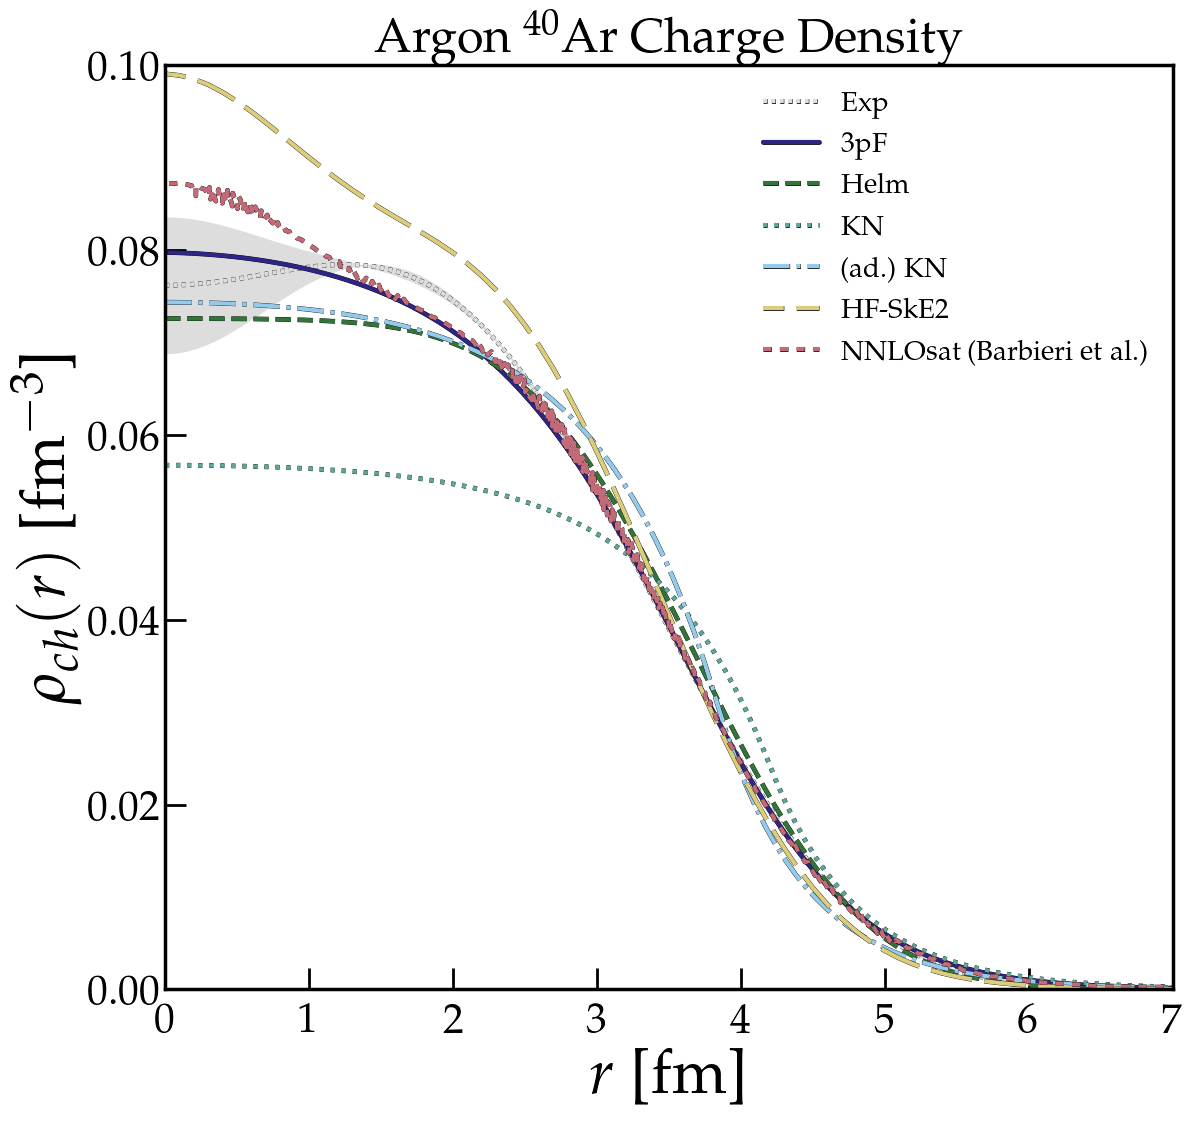

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.integrate import quad

plt.style.use('sty.mplstyle')
path_effects=[pe.Stroke(linewidth=3.4, foreground='k'), pe.Normal()]

lw = 3
colors = {'Exp':'#DDDDDD', '3pF':'#2E2585', 'Helm':'#337538', 'KN':'#5DA899', 'adKN':'#94CBEC',
          'HF-SkE2':'#DCCD7D', 'Barbieri':'#C26A77', 'Payne':'#9F4A96'} #7E2954

#===============================================================
#=================   Define useful constants   =================
#===============================================================
ArZ = 18
ArA = 40

#===============================================================
#================   Define the charge density   ================
#===============================================================
ArFB_R = 9.0 # fm
ArFB_a = np.array([1.69158e-3, 3.0740e-3, 1.1223e-3, -9.313e-4, -7.543e-4, -2.4e-6, 5.11e-5,
                   -2.289e-5, 6.65e-6, -1.10e-6, -2.4e-7, 3.4e-7, -2.1e-7, 1.0e-7, -4.3e-8]) # fm^-3
ArFB_aerr = np.array([2.95e-6, 1.497e-5, 1.113e-5, 7.11e-6, 1.32e-5, 6.51e-5, 1.049e-4,
                      7.28e-5, 4.56e-5, 2.85e-5, 1.77e-5, 1.09e-5, 6.59e-6, 3.8e-6, 2.2e-6])

def ArRHO_Exp(r):
    rho = np.zeros_like(r)
    rho_err = np.zeros_like(r)
    cond = r < ArFB_R
    for i in range(len(ArFB_a)):
        n = i + 1
        rho[cond] += ArFB_a[i] * np.sin(np.pi*r[cond]*n/ArFB_R)/ (np.pi*r[cond]*n/ArFB_R)
        rho_err[cond] += ArFB_aerr[i] * np.sin(np.pi*r[cond]*n/ArFB_R)/ (np.pi*r[cond]*n/ArFB_R)
    rho *= 18.0
    rho_err *= 18.0
    return rho, rho_err
#===============================================================
#===============================================================
Ar3pF_c = 3.73 # fm
Ar3pF_z = 0.62 # fm
Ar3pF_w = -0.19
Ar3pF_Rlim = np.sqrt(-1/Ar3pF_w)*Ar3pF_c # fm (Charge density is negative thereafter)

def Ar3pF_NORM(r):
    num = 1.0 + Ar3pF_w * (r/Ar3pF_c)**2
    denom = 1.0 + np.exp( (r-Ar3pF_c)/Ar3pF_z )
    return r**2 * num/denom

Ar3pF_RHO0, _ = quad(Ar3pF_NORM, 0.0, Ar3pF_Rlim)
Ar3pF_RHO0 = ArZ/4.0/np.pi/Ar3pF_RHO0 # fm^{-3}

def ArRHO_3pF(r):
    num = 1.0 + Ar3pF_w * (r/Ar3pF_c)**2
    denom = 1.0 + np.exp( (r-Ar3pF_c)/Ar3pF_z )
    return Ar3pF_RHO0*num/denom
#===============================================================
#===============================================================
ArHelm_r0 = 0.52 # fm
ArHelm_s = 0.9 # fm
ArHelm_R0 = np.sqrt( ( 1.23*ArA**(1/3) - 0.6 )**2 + 7.0*(np.pi*ArHelm_r0)**2/3.0 - 5.0*ArHelm_s**2 ) # fm

def ArIntHelm(x, r):
    fun = x * np.exp(-x**2/2.0/ArHelm_s**2) * ( np.exp(r*x/ArHelm_s**2) - np.exp(-r*x/ArHelm_s**2) )
    return fun

def ArRHO_Helm(r):
    result, _ = quad(ArIntHelm, 0.0, ArHelm_R0, args=(r,))
    result *= 3.0 * (2.0*np.pi)**(-3.0/2.0) * np.exp(-r**2/2.0/ArHelm_s**2)
    result *= 1/(2.0*ArHelm_s*r*ArHelm_R0**3)
    result *= ArZ
    return result

ArRHO_Helm = np.vectorize(ArRHO_Helm)
#===============================================================
#===============================================================
ArKN_RA = 1.23*ArA**(1/3) # fm
ArKN_ak = 0.7 # fm

def ArIntKN(x, r):
    fun = x * ( np.exp( -np.abs(r-x)/ArKN_ak ) - np.exp( -(r+x)/ArKN_ak ) )
    return fun

def ArRHO_KN(r):
    result, _ = quad(ArIntKN, 0.0, ArKN_RA, args=(r,))
    result *= 3.0/8.0/np.pi/r/ArKN_ak/ArKN_RA**3
    result *= ArZ
    return result

ArRHO_KN = np.vectorize(ArRHO_KN)
#===============================================================
#===============================================================
AradKN_r0 = 3.427 # fm
AradKN_ak = 0.7 # fm
AradKN_RA = np.sqrt( 5.0*AradKN_r0**2/3.0 - 10.0*AradKN_ak**2 ) # fm

def ArIntadKN(x, r):
    fun = x * ( np.exp( -np.abs(r-x)/AradKN_ak ) - np.exp( -(r+x)/AradKN_ak ) )
    return fun

def ArRHO_adKN(r):
    result, _ = quad(ArIntadKN, 0.0, AradKN_RA, args=(r,))
    result *= 3.0/8.0/np.pi/r/AradKN_ak/AradKN_RA**3
    result *= ArZ
    return result

ArRHO_adKN = np.vectorize(ArRHO_adKN)

#===============================================================
#==============   Import numeric charge density   ==============
#===============================================================
ArBarbieri_r = np.loadtxt('../csv/FormFactors/rho_ch_40Ar.dat', usecols=0)
ArBarbieri_rho = np.loadtxt('../csv/FormFactors/rho_ch_40Ar.dat', usecols=1)

ArHFSkE2_r = np.loadtxt('../csv/FormFactors/p_density_HF-SkE2.dat', usecols=0)
ArHFSkE2_rho = np.loadtxt('../csv/FormFactors/p_density_HF-SkE2.dat', usecols=1)

#===============================================================
#===============   Plotting the charge density   ===============
#===============================================================
fig = plt.figure()
ax = fig.add_subplot()

rr = np.linspace(1e-5, 7, 100) # 0 to 10 fm

ArRHO_Expvals, ArRHO_Experr = ArRHO_Exp(rr)
ArRHO_3pFvals = ArRHO_3pF(rr)
ArRHO_Helmvals = ArRHO_Helm(rr)
ArRHO_KNvals = ArRHO_KN(rr)
ArRHO_adKNvals = ArRHO_adKN(rr)

ax.plot(rr, ArRHO_Expvals, color=colors['Exp'], ls= (0,(1,1)), lw=lw, label='Exp', path_effects=path_effects)
ax.fill_between(rr, ArRHO_Expvals + ArRHO_Experr, ArRHO_Expvals - ArRHO_Experr, color=colors['Exp'])

ax.plot(rr, ArRHO_3pFvals, color=colors['3pF'], ls='-', lw=lw, label='3pF', path_effects = path_effects)
ax.plot(rr, ArRHO_Helmvals, color=colors['Helm'], ls='--', lw=lw, label='Helm', path_effects = path_effects)
ax.plot(rr, ArRHO_KNvals, color=colors['KN'], ls=':', lw=lw, label='KN', path_effects = path_effects)
ax.plot(rr, ArRHO_adKNvals, color=colors['adKN'], ls='-.', lw=lw, label='(ad.) KN', path_effects = path_effects)
ax.plot(ArHFSkE2_r, ArHFSkE2_rho, color=colors['HF-SkE2'], ls=(5, (10, 3)), lw=lw, label='HF-SkE2', path_effects = path_effects)
ax.plot(ArBarbieri_r, ArBarbieri_rho, color=colors['Barbieri'], ls=(0, (2, 2)), lw=lw, label='NNLOsat (Barbieri et al.)', path_effects = path_effects)

ax.legend(fontsize=20, loc='upper right', frameon=False, framealpha=1, edgecolor='k', fancybox=False)
ax.set_xlabel(r'$r$ [fm]')
ax.set_ylabel(r'$\rho_{ch}(r)$ [fm$^{-3}$]')
ax.set_title(r'Argon $^{40}$Ar Charge Density')
ax.tick_params(which='both', right=False, top=False)
ax.set_xlim([0,rr.max()])
ax.set_ylim(bottom=0, top=0.10)

plt.savefig('../Plots/Figures_PDF/rho_FF_u1/40ArChDensity.pdf', transparent=False, bbox_inches='tight')
plt.savefig('../Plots/Figures_PNG/rho_FF_u1/40ArChDensity.png', transparent=False, bbox_inches='tight')